In [9]:
import rdkit
from rdkit.Chem import Draw
from xml.dom import minidom
import os

In [2]:
def _get_svg_doc(mol):
    """
    Draws molecule a generates SVG string.
    :param mol:
    :return:
    """
    dm = Draw.PrepareMolForDrawing(mol)
    d2d = Draw.MolDraw2DSVG(300, 300)
    d2d.DrawMolecule(dm)
    d2d.AddMoleculeMetadata(dm)
    d2d.FinishDrawing()
    svg = d2d.GetDrawingText()

    doc = minidom.parseString(svg)  # this is the trick never used
    return doc,svg

In [2]:
[str(x) for x in range(10)]

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

In [3]:
node='CH3'

In [61]:
# https://github.com/rdkit/rdkit/issues/2496
smiles="C1([O+]2CC2)=CC=CC=C1"
smiles="C[O+2]1(CC1)C2=CC=CC=C2"
smiles="Br[O+2]1(C2=CC=CC=C2)[N-]C1([FH+])[I-]C"
# mol = rdkit.Chem.MolFromSmiles(smiles,sanitize=False)
mol = rdkit.Chem.MolFromSmiles(smiles)
smiles_aro=rdkit.Chem.MolToSmiles(mol,kekuleSmiles=False)
dm = Draw.PrepareMolForDrawing(mol)
d2d = Draw.MolDraw2DSVG(300, 300)
d2d.DrawMolecule(dm)
d2d.AddMoleculeMetadata(dm)
d2d.FinishDrawing()
svg = d2d.GetDrawingText()

In [62]:
aa=[81.0,82.8,83.7,84.7,84.7,84.7,83.0,81.3,78.2,71.9,71.9,77.4,80.7,82.3,83.9,83.9,83.9,81.0,74.4,74.4,77.4,79.3,80.3,81.2,81.2,81.2,77.4,74.4,78.2,80.0,81.0,82.0,82.0,82.0,80.9,79.9,77.8,74.4,74.4,78.2]
sum(aa)/len(aa)

79.82500000000002

In [59]:
bb=[ 211.6, 212.1, 213.2, 214.3, 215.9, 218.5, 220.0, 221.5, 221.5, 221.5, 202.6, 202.6, 202.6, 203.9, 205.2, 207.6, 210.5, 211.6, 204.8, 210.7, 210.7, 210.7, 209.9, 209.1, 207.6, 204.8, 204.8, 204.8, 219.3, 219.3, 218.5, 217.6, 215.9, 214.4, 213.6, 212.8, 212.8, 212.8, 219.3, 219.3,]
sum(set(bb))/len(set(bb))

212.23181818181817

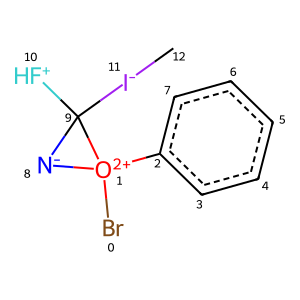

In [63]:
opts = Draw.MolDrawOptions()
opts.addAtomIndices = True
opts.addStereoAnnotation = True
Draw.MolToImage(mol, kekulize=False,options=opts)

In [66]:
doc,svg=_get_svg_doc(mol)
svg

'<?xml version=\'1.0\' encoding=\'iso-8859-1\'?>\n<svg version=\'1.1\' baseProfile=\'full\'\n              xmlns=\'http://www.w3.org/2000/svg\'\n                      xmlns:rdkit=\'http://www.rdkit.org/xml\'\n                      xmlns:xlink=\'http://www.w3.org/1999/xlink\'\n                  xml:space=\'preserve\'\nwidth=\'300px\' height=\'300px\' viewBox=\'0 0 300 300\'>\n<!-- END OF HEADER -->\n<rect style=\'opacity:1.0;fill:#FFFFFF;stroke:none\' width=\'300.0\' height=\'300.0\' x=\'0.0\' y=\'0.0\'> </rect>\n<path class=\'bond-0 atom-0 atom-1\' d=\'M 112.5,229.0 L 110.6,209.3\' style=\'fill:none;fill-rule:evenodd;stroke:#7F4C19;stroke-width:2.0px;stroke-linecap:butt;stroke-linejoin:miter;stroke-opacity:1\' />\n<path class=\'bond-0 atom-0 atom-1\' d=\'M 110.6,209.3 L 108.6,189.7\' style=\'fill:none;fill-rule:evenodd;stroke:#FF0000;stroke-width:2.0px;stroke-linecap:butt;stroke-linejoin:miter;stroke-opacity:1\' />\n<path class=\'bond-1 atom-1 atom-2\' d=\'M 137.7,170.1 L 152.2,166.1\'

In [82]:
charges_ats=[]
charges_ids=[]
for path in doc.getElementsByTagName('rdkit:atom'):
    a_str=path.getAttribute('atom-smiles')
    a_id=path.getAttribute('idx')
    # #get charge coords
    if '-' in a_str or  '+' in a_str:
        charges_ats.append((a_str,int(a_id)-1))#need zero start
        charges_ids.append(f"atom-{int(a_id)-1}")
        print([path.getAttribute('atom-smiles'),path.getAttribute('idx')])

['[O+2]', '2']
['[N-]', '9']
['[FH+]', '11']
['[I-]', '12']


In [83]:
import re
import numpy as np

['atom-1', 'atom-8', 'atom-10', 'atom-11']

In [95]:
# doc
for path in doc.getElementsByTagName('path'):
    str_xxx=path.getAttribute('class')
    if 'bond' not in str_xxx and 'atom' in str_xxx :
        if str_xxx in charges_ids:
            coords_str=path.getAttribute('d')
            # print([str_xxx],coords)
            # Extract the numbers using regular expressions
            numbers = re.findall(r'[-+]?\d*\.\d+|\d+', coords_str)
            # Convert the numbers to floats and group them into pairs (x, y coordinates)
            coords_ = [(float(numbers[i]), float(numbers[i+1])) for i in range(0, len(numbers), 2)]
            # Convert the list of tuples to a 2D float array (list of lists)
            coords_2d_array = [list(coord) for coord in coords_]
            coords_array = np.array(coords_2d_array)
            # Compute the mean of the x and y coordinates
            mean_coord = np.mean(coords_array, axis=0)
            print([str_xxx],mean_coord)


['atom-1'] [107.28235294 178.86764706]
['atom-1'] [122.040625 171.1875  ]
['atom-1'] [131.53076923 173.40769231]
['atom-8'] [ 46.08421053 173.20526316]
['atom-8'] [ 58.4  168.52]
['atom-10'] [21.30769231 79.43846154]
['atom-10'] [36.31818182 78.04545455]
['atom-10'] [47.40769231 75.16923077]
['atom-11'] [130.66  85.66]
['atom-11'] [137.16  82.12]


In [93]:
import re
import numpy as np

In [94]:
# Extract the numbers using regular expressions
numbers = re.findall(r'[-+]?\d*\.\d+|\d+', coords)
# Convert the numbers to floats and group them into pairs (x, y coordinates)
coords_ = [(float(numbers[i]), float(numbers[i+1])) for i in range(0, len(numbers), 2)]
# Convert the list of tuples to a 2D float array (list of lists)
coords_2d_array = [list(coord) for coord in coords_]
coords_array = np.array(coords_2d_array)
# Compute the mean of the x and y coordinates
mean_coord = np.mean(coords_array, axis=0)
mean_coord

array([137.16,  82.12])

In [91]:
coords_

[(134.8, 81.6), (140.7, 81.6), (140.7, 82.9), (134.8, 82.9), (134.8, 81.6)]

In [26]:
svg#需要去掉\n   \' as ' 转义符

'<?xml version=\'1.0\' encoding=\'iso-8859-1\'?>\n<svg version=\'1.1\' baseProfile=\'full\'\n              xmlns=\'http://www.w3.org/2000/svg\'\n                      xmlns:rdkit=\'http://www.rdkit.org/xml\'\n                      xmlns:xlink=\'http://www.w3.org/1999/xlink\'\n                  xml:space=\'preserve\'\nwidth=\'300px\' height=\'300px\' viewBox=\'0 0 300 300\'>\n<!-- END OF HEADER -->\n<rect style=\'opacity:1.0;fill:#FFFFFF;stroke:none\' width=\'300.0\' height=\'300.0\' x=\'0.0\' y=\'0.0\'> </rect>\n<path class=\'bond-0 atom-0 atom-1\' d=\'M 79.6,200.4 L 82.1,179.2\' style=\'fill:none;fill-rule:evenodd;stroke:#7F4C19;stroke-width:2.0px;stroke-linecap:butt;stroke-linejoin:miter;stroke-opacity:1\' />\n<path class=\'bond-0 atom-0 atom-1\' d=\'M 82.1,179.2 L 84.5,158.0\' style=\'fill:none;fill-rule:evenodd;stroke:#FF0000;stroke-width:2.0px;stroke-linecap:butt;stroke-linejoin:miter;stroke-opacity:1\' />\n<path class=\'bond-1 atom-1 atom-2\' d=\'M 118.5,144.0 L 135.4,143.0\' sty

In [25]:
Draw.MolToFile(mol,'rdkit_molP2.svg')#check for details, GetDrawingText() svg seems not vailed, use this 
#not sure they are same drawing svg?
#https://github.com/rdkit/rdkit/issues/2641
# https://www.w3schools.com/graphics/svg_path.asp

In [10]:
os.getcwd()

'/home/jovyan/rt-detr/rt-detr/src/solver'

In [46]:
# from rdkit.Chem.Draw import IPythonConsole, rdMolDraw2D
# from IPython.display import SVG
# from rdkit.Chem import AllChem, MolFromSmiles

# m = MolFromSmiles('CC(C)Cc1ccc(cc1)C(C)C(=O)O')
# m.Compute2DCoords()  # necessary for drawing!

# drawer = rdMolDraw2D.MolDraw2DSVG(400,200)
# opts = drawer.drawOptions()
# for i in range(m.GetNumAtoms()):
#     opts.atomLabels[i] = str(i)
# drawer.DrawMolecule(m)
# drawer.FinishDrawing()
# svg = drawer.GetDrawingText().replace('svg:','')
# SVG(svg)